# Fig: typical trajectories in different regimes
ISHII Hidemasa

In [1]:
using CSV, DataFrames, DataFramesMeta
using Statistics, Integrals, DifferentialEquations, DiffEqCallbacks
using CairoMakie
using Makie.GeometryBasics
import ColorSchemes as cs

In [2]:
# fixed parameters
r = 0.05
D = 0.005
ξ = 0.5

0.5

In [3]:
Kvals = [0.1, 1.0, 100.0]
N = 64
seed = 634

634

In [4]:
# SDE functions
function f_global!(du, u, p, t)
    (; r, K, N) = p  # expand parameters
    du .= -u .* (u .- r) .* (u .- 1) .+ K * (sum(u) / N .- u)
end

function g!(du, u, p, t)
    du .= p.σ
end

g! (generic function with 1 method)

In [5]:
v_res = []
for K in Kvals
    @info "working on K=$K..."
    p = (r=r, K=K, N=N, σ=sqrt(2D), ξ=ξ)
    prob = SDEProblem(f_global!, g!, zeros(N), (0.0, 50.0), p)
    sol = solve(prob, SOSRA(); 
        seed=seed, saveat=0.1, abstol=5e-4, reltol=1e-3, maxiters=1e11,
    )
    data = hcat(sol.u...)
    push!(v_res, (t=sol.t, data=data))
end

┌ Info: working on K=0.1...
└ @ Main /workdir/src/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sdnNjb2RlLXJlbW90ZQ==.jl:3
┌ Info: working on K=1.0...
└ @ Main /workdir/src/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sdnNjb2RlLXJlbW90ZQ==.jl:3
┌ Info: working on K=100.0...
└ @ Main /workdir/src/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W5sdnNjb2RlLXJlbW90ZQ==.jl:3


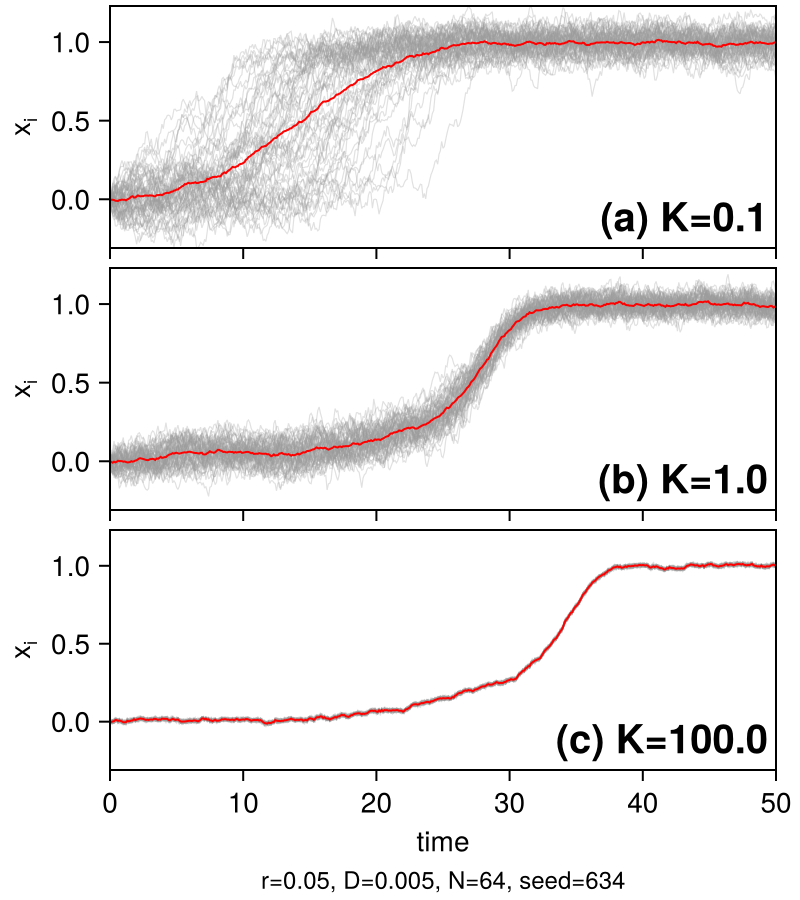

In [6]:
let ifsave=true
    fig = Figure(size=(400, 450), figure_padding=(3, 12, 3, 3))
    axopts = (
        xautolimitmargin=(0, 0), xgridvisible=false, 
        yautolimitmargin=(0, 0), ylabel=rich("x", subscript("i")), ygridvisible=false,
    )
    ax1 = Axis(fig[1, 1]; xticklabelsvisible=false, axopts...)
    ax2 = Axis(fig[2, 1]; xticklabelsvisible=false, axopts...)
    ax3 = Axis(fig[3, 1]; xlabel="time", axopts...)
    for ax in (ax2, ax3)
        linkaxes!(ax1, ax)
    end
    t_lab = ("a", "b", "c")
    for (ax, lab, K, res) in zip((ax1, ax2, ax3), t_lab, Kvals, v_res)
        text!(ax, 1, 0; 
            text="($lab) K=$K", font=:bold, fontsize=20,
            space=:relative, align=(:right, :bottom), offset=(-4, 4)
        )
        for i in 1:N
            lines!(ax, res.t, res.data[i,:], color=:gray60, alpha=0.3, linewidth=0.6)
        end
        lines!(ax, res.t, mean.(eachcol(res.data)), color=:red, linewidth=1.0)
    end
    Label(fig[end+1, 1],
        "r=$r, D=$D, N=$N, seed=$seed", tellwidth=false, 
        fontsize=12,
    )
    rowgap!(fig.layout, 5)
    if ifsave save("output/fig-trajectories.pdf", fig) end
    display(fig)
end;